<a href="https://colab.research.google.com/github/HyperActivated2046/CTF-Writeups-2024/blob/main/Amos_SGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ✅ STEP 1: Download and run notebook from GitHub (no Google Drive required)

import requests
import nbformat
import joblib, os, numpy as np
from IPython import get_ipython

def run_notebook_from_github(url):
    """
    Downloads and executes a Jupyter notebook from a GitHub raw URL.

    Parameters:
    url (str): Raw GitHub URL to a .ipynb notebook file
    """
    print("Downloading notebook from GitHub...")
    try:
        response = requests.get(url)
        response.raise_for_status()
    except Exception as e:
        print(f"Failed to download notebook: {e}")
        return

    print("📖 Parsing notebook content...")
    try:
        notebook = nbformat.reads(response.text, as_version=4)
    except Exception as e:
        print(f"Failed to parse notebook: {e}")
        return

    ipython = get_ipython()
    print("Running notebook cells...\n")

    for i, cell in enumerate(notebook.cells):
        if cell.cell_type == 'code':
            try:
                print(f"▶  Executing cell [{i + 1}]...")
                ipython.run_cell(cell.source)
            except Exception as e:
                print(f" Error in cell [{i + 1}]: {e}")

    print("\n All executable cells have been processed.")

# 🔗 Use your GitHub notebook URL
notebook_url = "https://raw.githubusercontent.com/Hushpuppyzac/DLI-Assignment/main/CleanedData.ipynb"

# ▶️ Run it
run_notebook_from_github(notebook_url)


📖 Parsing notebook content...
Running notebook cells...

▶  Executing cell [2]...

             INITIAL DATASET INFORMATION             
Total rows before any cleaning: 225,745
Initial Label distribution (raw data):


,count
Label,
DDoS,128027
BENIGN,97718



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length M

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.00000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,8879.61946,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,164.826715,214.907242,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,19754.64740,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,504.892965,797.411073,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.00000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.00000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.00000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.00000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65532.00000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08




--- DataFrame Columns after stripping whitespace and renaming ---
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', '

...


Final Columns (Testing Set after Feature Extraction):
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'ECE Flag Count', 'Down/Up Ra

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,pkt_length_diff,pkt_length_var_ratio,byte_ratio,duration_per_packet,avg_to_max_ratio
0,-0.496462,-0.511479,-0.245222,-0.168530,-0.303820,-0.138477,-0.292419,0.082431,-0.269685,-0.294430,...,-0.220676,-0.469879,-0.279191,-0.475267,-0.390354,-0.788134,-0.663447,-0.042185,-0.558311,0.632065
1,2.424285,-0.513378,0.004044,-0.123929,3.008621,-0.140547,5.431752,-0.182254,3.902286,5.708969,...,-0.220676,-0.469879,-0.279191,-0.475267,-0.390354,2.285842,1.203662,-0.042170,-0.578708,-0.982426
2,2.322853,-0.514890,-0.245222,-0.168530,-0.317288,-0.141196,-0.315716,-0.182254,-0.355898,-0.294430,...,-0.220676,-0.469879,-0.279191,-0.475267,-0.390354,-0.804659,-1.136167,-0.042185,-0.581654,-1.275411
3,2.147016,-0.221781,-0.245222,0.009873,-0.315569,-0.140448,-0.312742,-0.148465,-0.344892,-0.294430,...,-0.204030,-0.041240,-0.279191,-0.126852,0.081679,-0.804659,-0.842734,-0.042185,0.087018,1.115593
4,-0.495185,-0.219132,0.004044,-0.213131,-0.308692,-0.141196,-0.312742,-0.148465,-0.344892,-0.294430,...,-0.217260,-0.036873,-0.279191,-0.123302,0.086489,-0.804659,-0.842734,0.058275,0.228007,1.183205



Sample of Scaled Testing Data (First 5 Rows):


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,pkt_length_diff,pkt_length_var_ratio,byte_ratio,duration_per_packet,avg_to_max_ratio
139654,2.095897,-0.360247,-0.245222,0.009873,-0.315569,-0.140448,-0.312742,-0.148465,-0.344892,-0.294430,...,-0.220676,-0.469879,-0.279191,-0.475267,-0.390354,-0.804659,-0.842734,-0.042185,-0.228870,1.115593
127815,-0.495185,-0.491359,-0.120589,0.009873,-0.309838,0.148192,-0.305803,-0.182254,-0.340001,-0.282545,...,-0.220676,-0.469879,-0.279191,-0.475267,-0.390354,0.751919,0.190441,-0.042185,-0.541403,-0.765248
111648,2.589378,-0.486148,-0.245222,0.054474,-0.315569,-0.140298,-0.312742,-0.148465,-0.344892,-0.294430,...,-0.220676,-0.469879,-0.279191,-0.475267,-0.390354,-0.804659,-0.842734,-0.042185,-0.525461,1.066421
76785,-0.495185,-0.512893,-0.120589,0.009873,-0.309838,0.148192,-0.305803,-0.182254,-0.340001,-0.282545,...,-0.220676,-0.469879,-0.279191,-0.475267,-0.390354,0.751919,0.190441,-0.042185,-0.578247,-0.765248
72328,-0.495185,-0.505281,0.004044,-0.213131,-0.308692,-0.141196,-0.312742,-0.148465,-0.344892,-0.294430,...,-0.220676,-0.469879,-0.279191,-0.475267,-0.390354,-0.804659,-0.842734,0.058275,-0.555356,1.183205




 All executable cells have been processed.


✅ Data ready for SGD Logistic:
  X_train: (152108, 73)  X_test: (44617, 73)
  y_train: (152108,)  (counts: [76054, 76054] )
  y_test : (44617,)  (counts: [19014, 25603] )
Epoch 01/20  train_acc: 0.9942  val_acc: 0.9940  train_loss: 0.0190  val_loss: 0.0206
Epoch 02/20  train_acc: 0.9983  val_acc: 0.9983  train_loss: 0.0174  val_loss: 0.0172
Epoch 03/20  train_acc: 0.9983  val_acc: 0.9983  train_loss: 0.0177  val_loss: 0.0179
Epoch 04/20  train_acc: 0.9983  val_acc: 0.9983  train_loss: 0.0168  val_loss: 0.0167
Epoch 05/20  train_acc: 0.9979  val_acc: 0.9976  train_loss: 0.0169  val_loss: 0.0171
Epoch 06/20  train_acc: 0.9981  val_acc: 0.9979  train_loss: 0.0165  val_loss: 0.0163
Epoch 07/20  train_acc: 0.9910  val_acc: 0.9913  train_loss: 0.0173  val_loss: 0.0166
Epoch 08/20  train_acc: 0.9970  val_acc: 0.9965  train_loss: 0.0170  val_loss: 0.0172
Epoch 09/20  train_acc: 0.9969  val_acc: 0.9964  train_loss: 0.0169  val_loss: 0.0170
Epoch 10/20  train_acc: 0.9932  val_acc: 0.9934  train_

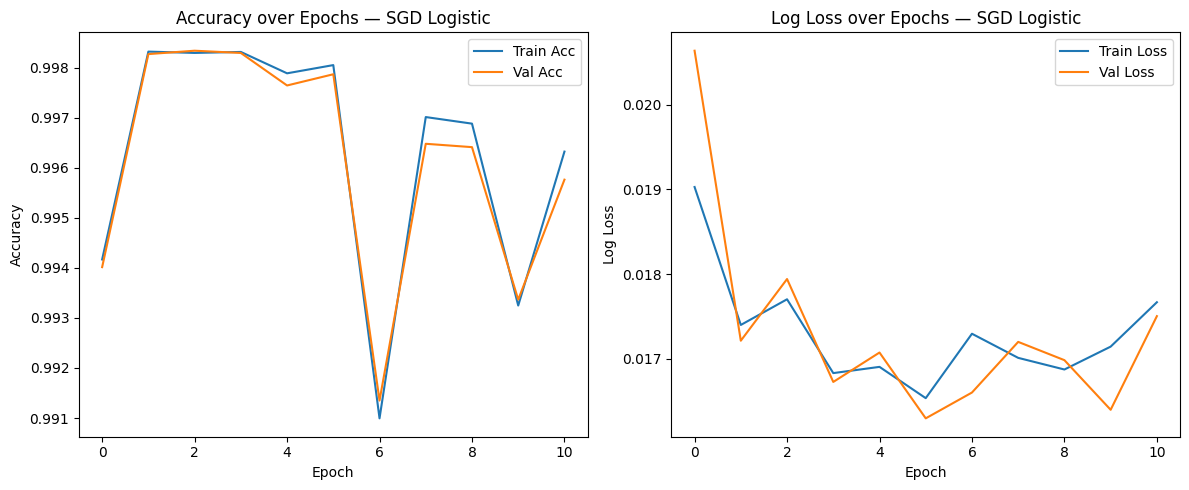

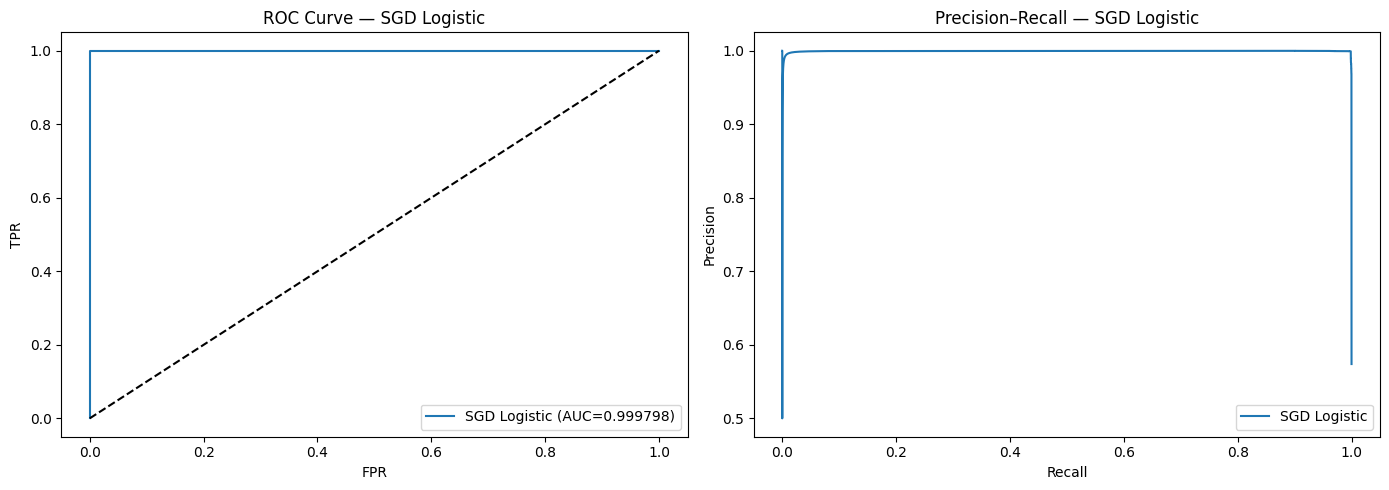

In [ ]:
# Single Algorithm WITH Epochs
# Algorithm: Logistic Regression via SGD (epochs with partial_fit)
# Step 1 created: X_train_scaled, X_test_scaled, y_train_bal (or y_train_balanced), y_test
import numpy as np, matplotlib.pyplot as plt, random
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
                             classification_report, log_loss)
from scipy.special import expit

np.random.seed(42); random.seed(42)

# Verify/alias preprocessed arrays from CleanedData.ipynb
needed = ["X_train_scaled", "X_test_scaled", "y_test"]
missing = [n for n in needed if n not in globals()]
if "y_train_bal" not in globals() and "y_train_balanced" in globals():
    y_train_bal = globals()["y_train_balanced"]
if "y_train_bal" not in globals():
    missing.append("y_train_bal (or y_train_balanced)")
if missing:
    raise NameError(f"❌ Preprocessed arrays not found: {missing}. Run CleanedData.ipynb first.")

# Ensure numpy arrays & int labels
def to_np(a):
    try:
        return a.values if hasattr(a, "values") else np.asarray(a)
    except Exception:
        return np.asarray(a)

X_tr = to_np(X_train_scaled)
X_te = to_np(X_test_scaled)
y_tr = to_np(y_train_bal).astype(int)
y_te = to_np(y_test).astype(int)

print("Data ready for SGD Logistic:")
print("  X_train:", X_tr.shape, " X_test:", X_te.shape)
print("  y_train:", y_tr.shape, " (counts:", np.bincount(y_tr).tolist(), ")")
print("  y_test :", y_te.shape,  " (counts:", np.bincount(y_te).tolist(), ")")


# Train Logistic Regression (SGD) with EPOCHS
EPOCHS     = 20        # adjust as needed
BATCH_SIZE = 2048      # mini-batch size
CLASSES    = np.array([0, 1])

sgd = SGDClassifier(
    loss="log_loss",     # Logistic regression with probabilities
    penalty="l2",
    alpha=1e-4,
    learning_rate="optimal",
    random_state=42
)

n = X_tr.shape[0]
idx = np.arange(n)
train_acc_hist, val_acc_hist = [], []
train_loss_hist, val_loss_hist = [], []

best_val_loss = np.inf
patience = 5          # Simple early stopping
wait = 0

for epoch in range(1, EPOCHS + 1):
    np.random.shuffle(idx)
    first = True
    for start in range(0, n, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n)
        b = idx[start:end]
        Xb, yb = X_tr[b], y_tr[b]
        if first:
            sgd.partial_fit(Xb, yb, classes=CLASSES)
            first = False
        else:
            sgd.partial_fit(Xb, yb)

    # End-of-epoch metrics
    if hasattr(sgd, "predict_proba"):
        tr_prob = sgd.predict_proba(X_tr)[:,1]
        va_prob = sgd.predict_proba(X_te)[:,1]
    else:
        tr_prob = expit(sgd.decision_function(X_tr))
        va_prob = expit(sgd.decision_function(X_te))

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= 0.5).astype(int)
    tr_acc = accuracy_score(y_tr, tr_pred)
    va_acc = accuracy_score(y_te, va_pred)
    tr_loss = log_loss(y_tr, tr_prob, labels=[0,1])
    va_loss = log_loss(y_te, va_prob, labels=[0,1])

    train_acc_hist.append(tr_acc); val_acc_hist.append(va_acc)
    train_loss_hist.append(tr_loss); val_loss_hist.append(va_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train_acc: {tr_acc:.4f}  val_acc: {va_acc:.4f}  "
          f"train_loss: {tr_loss:.4f}  val_loss: {va_loss:.4f}")

    # Simple early stopping on val_loss
    if va_loss < best_val_loss - 1e-6:
        best_val_loss = va_loss
        wait = 0
        best_state = sgd.__dict__.copy()  # Lightweight snapshot of coef_, intercept_
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch} (no val_loss improvement for {patience} epochs).")
            break

# Restore best weights if early stopped
if 'best_state' in locals():
    for k, v in best_state.items():
        try:
            setattr(sgd, k, v)
        except Exception:
            pass

# Final Evaluation
if hasattr(sgd, "predict_proba"):
    y_prob = sgd.predict_proba(X_te)[:,1]
else:
    y_prob = expit(sgd.decision_function(X_te))
y_pred = (y_prob >= 0.5).astype(int)

print("\n" + "="*60)
print("     SGD Logistic Regression — FINAL EVALUATION      ")
print("="*60)
print("Confusion Matrix:")
print(confusion_matrix(y_te, y_pred))
print("\nClassification Report:")
print(classification_report(y_te, y_pred, digits=6))
print(f"Accuracy : {accuracy_score(y_te, y_pred):.6f}")
print(f"Precision: {precision_score(y_te, y_pred):.6f}")
print(f"Recall   : {recall_score(y_te, y_pred):.6f}")
print(f"F1 Score : {f1_score(y_te, y_pred):.6f}")
print(f"ROC AUC  : {roc_auc_score(y_te, y_prob):.6f}")
print("="*60 + "\n")

# Learning Curves + ROC/PR
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist,   label="Val Acc")
plt.title("Accuracy over Epochs — SGD Logistic")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist,   label="Val Loss")
plt.title("Log Loss over Epochs — SGD Logistic")
plt.xlabel("Epoch"); plt.ylabel("Log Loss"); plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(14,5))
# ROC
plt.subplot(1,2,1)
fpr, tpr, _ = roc_curve(y_te, y_prob)
plt.plot(fpr, tpr, label=f"SGD Logistic (AUC={roc_auc_score(y_te, y_prob):.6f})")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve — SGD Logistic")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
# PR
plt.subplot(1,2,2)
prec, rec, _ = precision_recall_curve(y_te, y_prob)
plt.plot(rec, prec, label="SGD Logistic")
plt.title("Precision–Recall — SGD Logistic")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()
plt.tight_layout(); plt.show()

# Save Trained SGD Logistic Model as a single pkl bundle
fitted_scaler = globals().get("scaler", None)
try:
    feature_names = list(X_train_scaled.columns)
except Exception:
    feature_names = [f"f{i}" for i in range(X_train_scaled.shape[1])]
# Collect final metrics (recompute to be safe)
final_metrics = {
    "accuracy":  float(accuracy_score(y_te, y_pred)),
    "precision": float(precision_score(y_te, y_pred)),
    "recall":    float(recall_score(y_te, y_pred)),
    "f1":        float(f1_score(y_te, y_pred)),
    "roc_auc":   float(roc_auc_score(y_te, y_prob))
}

# Training history (from the epoch loop above)
history_dict = {
    "train_acc":  [float(x) for x in train_acc_hist],
    "val_acc":    [float(x) for x in val_acc_hist],
    "train_loss": [float(x) for x in train_loss_hist],
    "val_loss":   [float(x) for x in val_loss_hist],
    "epochs_run": len(train_acc_hist)
}

# Build the bundle
bundle = {
    "type": "ddos_sgd_logistic_v1",
    "model": sgd,                        # sklearn estimator (picklable)
    "scaler": fitted_scaler,             # may be None if not available
    "feature_names": feature_names,
    "classes": [0, 1],
    "threshold": 0.5,                    # decision threshold used for y_pred
    "metrics": final_metrics,
    "history": history_dict,
}

# Save to Google Drive (adjust the folder if you like)
save_path = "/content/drive/MyDrive/Colab Notebooks/DDOS/sgd_logistic_bundle.pkl"

os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(bundle, save_path)

print("Saved model bundle to:", save_path)

# (Optional) quick load test to verify the file
_loaded = joblib.load(save_path)
print("🔎 Bundle keys:", list(_loaded.keys()))
print("🔎 Feature count:", len(_loaded['feature_names']))
print("🔎 Metrics snapshot:", _loaded['metrics'])